In [1]:
# Cyclistic Bike-share analysis case study

## 1. Ask - Business task
## 2. Prepare – Data Source
## 3. Process – Data Cleaning
## 4. Analyze – Data Exploration
## 5. Share – Key Visualizations
## 6. Act – Recommendations

## 1. Ask – Business Task

The objective of this analysis is to understand how annual members and casual riders use Cyclistic bikes differently. These insights will help the marketing team develop strategies to convert casual riders into annual members.

## 2. Prepare – Data Source

The data used for this analysis is Cyclistic’s historical bike trip data from the previous 12 months. The dataset includes ride information such as ride start time, end time, ride type, and user type (member or casual).

In [2]:
import pandas as pd
import os

# List all files in the dataset folder
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/fabianstamp/2021-divy-tripdata/202110-divvy-tripdata.csv
/kaggle/input/datasets/fabianstamp/2021-divy-tripdata/202105-divvy-tripdata.csv
/kaggle/input/datasets/fabianstamp/2021-divy-tripdata/202109-divvy-tripdata.csv
/kaggle/input/datasets/fabianstamp/2021-divy-tripdata/202111-divvy-tripdata.csv
/kaggle/input/datasets/fabianstamp/2021-divy-tripdata/202107-divvy-tripdata.csv
/kaggle/input/datasets/fabianstamp/2021-divy-tripdata/202108-divvy-tripdata.csv
/kaggle/input/datasets/fabianstamp/2021-divy-tripdata/202106-divvy-tripdata.csv
/kaggle/input/datasets/fabianstamp/2021-divy-tripdata/202101-divvy-tripdata.csv
/kaggle/input/datasets/fabianstamp/2021-divy-tripdata/202103-divvy-tripdata.csv
/kaggle/input/datasets/fabianstamp/2021-divy-tripdata/202104-divvy-tripdata.csv
/kaggle/input/datasets/fabianstamp/2021-divy-tripdata/202102-divvy-tripdata.csv
/kaggle/input/datasets/fabianstamp/2021-divy-tripdata/202112-divvy-tripdata.csv


In [3]:
import os
print(os.listdir("/kaggle/input"))

['datasets']


In [4]:
import os
print(os.listdir("/kaggle/input/datasets"))

['fabianstamp']


In [5]:
import os
print(os.listdir("/kaggle/input/datasets/fabianstamp"))

['2021-divy-tripdata']


In [6]:
import pandas as pd
import glob

folder_path = "/kaggle/input/datasets/fabianstamp/2021-divy-tripdata/"

csv_files = glob.glob(folder_path + "*.csv")

print("Number of CSV files found:", len(csv_files))

df_list = [pd.read_csv(file) for file in csv_files]
df = pd.concat(df_list, ignore_index=True)

df.shape

Number of CSV files found: 12


(5595063, 13)

In [7]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5595063 entries, 0 to 5595062
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             object 
 1   rideable_type       object 
 2   started_at          object 
 3   ended_at            object 
 4   start_station_name  object 
 5   start_station_id    object 
 6   end_station_name    object 
 7   end_station_id      object 
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       object 
dtypes: float64(4), object(9)
memory usage: 554.9+ MB


## 3. Process – Data Cleaning

In this phase, the data will be cleaned and prepared for analysis by converting date columns, creating a ride duration variable, and removing invalid or unrealistic records.

In [8]:
#convert date cols to datetime
df['started_at']=pd.to_datetime(df['started_at'])
df['ended_at']=pd.to_datetime(df['ended_at'])

In [9]:
df['ride_length'] = df['ended_at'] - df['started_at']

In [10]:
df['ride_length'] = df['ride_length'].dt.total_seconds() / 60

In [11]:
df[['ride_length']].describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5595063 entries, 0 to 5595062
Data columns (total 14 columns):
 #   Column              Dtype         
---  ------              -----         
 0   ride_id             object        
 1   rideable_type       object        
 2   started_at          datetime64[ns]
 3   ended_at            datetime64[ns]
 4   start_station_name  object        
 5   start_station_id    object        
 6   end_station_name    object        
 7   end_station_id      object        
 8   start_lat           float64       
 9   start_lng           float64       
 10  end_lat             float64       
 11  end_lng             float64       
 12  member_casual       object        
 13  ride_length         float64       
dtypes: datetime64[ns](2), float64(5), object(7)
memory usage: 597.6+ MB


In [12]:
#remove negative ride lengths
df=df[df['ride_length']>0]

In [13]:
#remove short rides
df=df[df['ride_length']>=1]


In [14]:
df[['ride_length']].describe()

,ride_length
count,5.509830e+06
mean,2.226888e+01
std,1.796884e+02
min,1.000000e+00
25%,6.950000e+00
50%,1.220000e+01
75%,2.201667e+01
max,5.594415e+04


In [15]:
#remove ouliers
#remove rides longer than 24 hours-1440 minutes
df=df[df['ride_length']<=1440]

## 4. Analyze – How Members and Casual Riders Use Bikes Differently

In this phase, the dataset is explored to identify patterns and differences 
between annual members and casual riders. The analysis focuses on ride duration, 
ride frequency, and usage trends across days and months.

In [16]:
df.groupby('member_casual')['ride_length'].mean()

member_casual
casual    27.233199
member    13.616867
Name: ride_length, dtype: float64

In [17]:
#total no of rides by usertype

df['member_casual'].value_counts()

member_casual
member    3014449
casual    2491365
Name: count, dtype: int64

In [18]:
#usage by day of week

df['day_of_week'] = df['started_at'].dt.day_name()
df.groupby(['day_of_week', 'member_casual'])['ride_id'].count()

day_of_week  member_casual
Friday       casual           358622
             member           438928
Monday       casual           282133
             member           409285
Saturday     casual           549685
             member           425089
Sunday       casual           473736
             member           369126
Thursday     casual           281940
             member           444375
Tuesday      casual           270389
             member           458096
Wednesday    casual           274860
             member           469550
Name: ride_id, dtype: int64

In [19]:
#avg ride length by day

df.groupby(['day_of_week', 'member_casual'])['ride_length'].mean()

day_of_week  member_casual
Friday       casual           25.277320
             member           13.310389
Monday       casual           27.593767
             member           13.212557
Saturday     casual           29.595224
             member           15.239522
Sunday       casual           31.486899
             member           15.573477
Thursday     casual           23.463642
             member           12.756359
Tuesday      casual           24.823986
             member           12.802183
Wednesday    casual           23.596461
             member           12.857807
Name: ride_length, dtype: float64

In [20]:
df['month'] = df['started_at'].dt.month


In [21]:
df.groupby(['month','member_casual'])['ride_id'].count()

month  member_casual
1      casual            17815
       member            77563
2      casual             9906
       member            38626
3      casual            82996
       member           142365
4      casual           134714
       member           197453
5      casual           252938
       member           269863
6      casual           364422
       member           352612
7      casual           435362
       member           373787
8      casual           407063
       member           385365
9      casual           358868
       member           385902
10     casual           253440
       member           367394
11     casual           105224
       member           248663
12     casual            68617
       member           174856
Name: ride_id, dtype: int64

In [22]:
#usage by hour

df['hour']=df['started_at'].dt.hour

In [23]:
df.groupby(['hour', 'member_casual'])['ride_id'].count().unstack()

member_casual,casual,member
hour,,
0,52974,32468
1,38536,21434
2,25065,12175
3,13802,7016
4,9761,8002
5,12337,29597
6,25383,80644
7,46127,147604
8,62726,170659


## 5. Share-data visualization
In this, key findings from the analysis are presented using viusalizations to clearly highlight differences between annual members and casual riders.

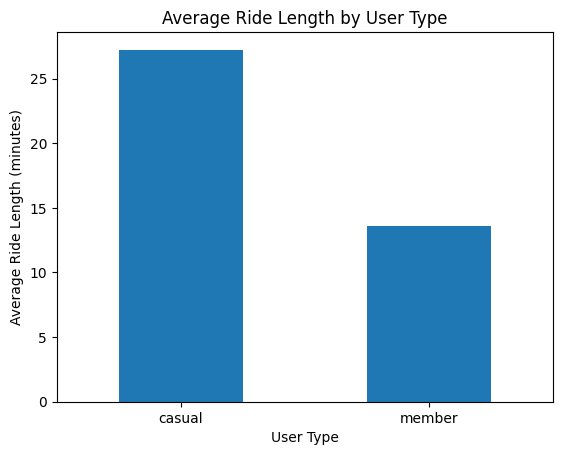

In [24]:
import matplotlib.pyplot as plt

avg_ride = df.groupby('member_casual')['ride_length'].mean()

avg_ride.plot(kind='bar')
plt.title("Average Ride Length by User Type")
plt.ylabel("Average Ride Length (minutes)")
plt.xlabel("User Type")
plt.xticks(rotation=0)
plt.show()

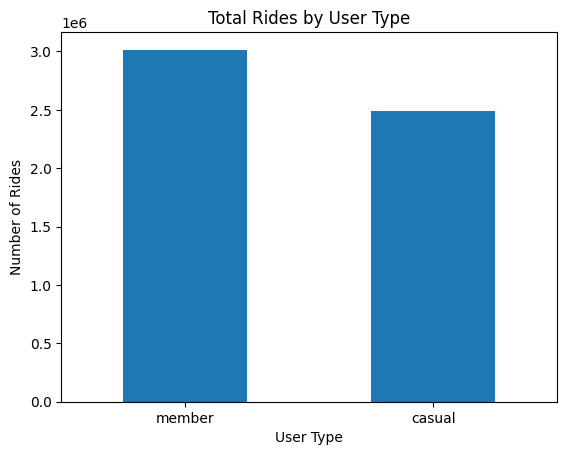

In [25]:
ride_counts = df['member_casual'].value_counts()

ride_counts.plot(kind='bar')
plt.title("Total Rides by User Type")
plt.ylabel("Number of Rides")
plt.xlabel("User Type")
plt.xticks(rotation=0)
plt.show()

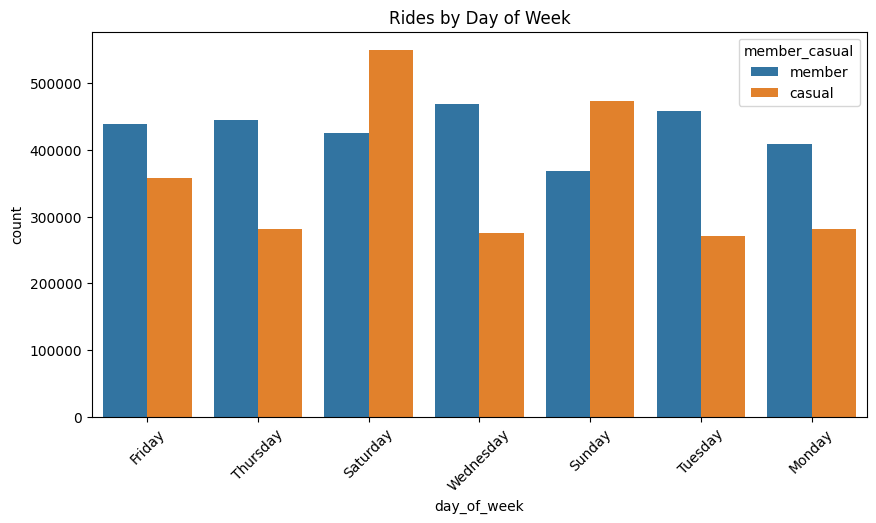

In [26]:
import seaborn as sns

plt.figure(figsize=(10,5))
sns.countplot(data=df, x='day_of_week', hue='member_casual')
plt.title("Rides by Day of Week")
plt.xticks(rotation=45)
plt.show()

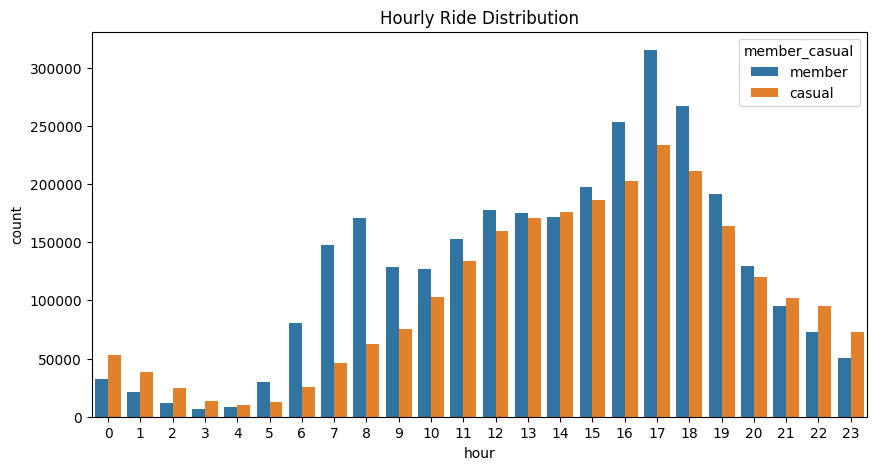

In [27]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='hour', hue='member_casual')
plt.title("Hourly Ride Distribution")
plt.show()

## 6. Act – Recommendations

Based on the analysis of ride patterns, the following actions are recommended to increase annual memberships:

### 1. Convert High-Usage Casual Riders
Casual riders who take longer trips or ride frequently during peak months can be targeted with personalized membership offers. Offering discounts after a certain number of rides may encourage them to switch to annual plans.

### 2. Focus on Weekend and Leisure Marketing
Since casual riders are more active during weekends and non-working hours, promotional campaigns should be concentrated on these periods. Messaging can highlight the value of unlimited rides with a membership plan.

### 3. Emphasize Cost and Convenience Benefits
Members tend to use bikes more consistently, especially during routine travel hours. Marketing efforts should clearly communicate long-term cost savings, convenience, and reliability of annual membership compared to single-use rides.

### 4. Seasonal Membership Promotions
During high-demand months, limited-time membership discounts or bundled offers can help convert casual riders who already demonstrate strong engagement.